# 🧹 Limpieza de datos y EDA

## Contexto
El dataset crudo contiene 3.780 publicaciones de MercadoLibre con precios 
en dos monedas distintas (USD y ARS), kilómetros como texto y valores anómalos.
Antes de cualquier análisis necesitamos un dataset consistente y confiable.

## Objetivo de esta fase
- Unificar precios a una sola moneda (USD)
- Convertir kilómetros a variable numérica
- Detectar y eliminar outliers con criterio estadístico
- Explorar visualmente la distribución de precios y km por modelo

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

df = pd.read_csv("../data/raw/precios_autos_raw.csv")
print(f"Shape: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nPrimeras filas:\n{df.head()}")

Shape: (3780, 7)

Tipos de datos:
modelo        object
titulo        object
precio       float64
moneda        object
año            int64
km            object
ubicacion     object
dtype: object

Primeras filas:
         modelo                           titulo      precio moneda   año  \
0  Toyota Etios       Toyota Etios 1.5 Sedan Xls     13200.0    US$  2018   
1  Toyota Etios       Toyota Etios 1.5 Sedan Xls  18100000.0      $  2018   
2  Toyota Etios       Toyota Etios 1.5 Sedan Xls  11500000.0      $  2016   
3  Toyota Etios             Toyota Etios 1.5 Xls     17000.0    US$  2021   
4  Toyota Etios  Toyota Etios 1.5 5 Ptas Xls 4at  18000000.0      $  2017   

           km                            ubicacion  
0   89.000 Km    Capital Federal - Capital Federal  
1  133.000 Km    Capital Federal - Capital Federal  
2  101.000 Km       Avellaneda - Bs.As. G.B.A. Sur  
3   80.000 Km     San Miguel - Bs.As. G.B.A. Norte  
4   47.000 Km  Vicente López - Bs.As. G.B.A. Norte  


In [19]:
response = requests.get("https://dolarhoy.com/", headers={"User-Agent": "Mozilla/5.0"}, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

# Ver todos los textos que contengan numeros de precio
for tag in soup.find_all(True):
    if tag.string and "$" in tag.string and any(c.isdigit() for c in tag.string):
        print(f"Tag: {tag.name} | Clase: {tag.get('class')} | Texto: {tag.string.strip()}")

Tag: div | Clase: ['val'] | Texto: $1380
Tag: div | Clase: ['val'] | Texto: $1400
Tag: div | Clase: ['val'] | Texto: $1380
Tag: div | Clase: ['val'] | Texto: $1400
Tag: div | Clase: ['val'] | Texto: $1370
Tag: div | Clase: ['val'] | Texto: $1420
Tag: div | Clase: ['val'] | Texto: $1427
Tag: div | Clase: ['val'] | Texto: $1434,30
Tag: div | Clase: ['val'] | Texto: $1482
Tag: div | Clase: ['val'] | Texto: $1483,10
Tag: div | Clase: ['val'] | Texto: $1475,20
Tag: div | Clase: ['val'] | Texto: $1475,30
Tag: div | Clase: ['val'] | Texto: $1846
Tag: div | Clase: ['nota__body'] | Texto: IRSA ganó casi $240.000 millones y reafirma su peso como gigante del negocio inmobiliario
Tag: div | Clase: ['nota__titulo'] | Texto: IRSA ganó casi $240.000 millones y reafirma su peso como gigante del negocio inmobiliario
Tag: h2 | Clase: None | Texto: IRSA ganó casi $240.000 millones y reafirma su peso como gigante del negocio inmobiliario
Tag: a | Clase: None | Texto: IRSA ganó casi $240.000 millones y rea

### Tipo de cambio en tiempo real
Scrapeamos el dólar blue de venta desde dolarhoy.com para convertir precios ARS → USD.
Usamos el blue y no el oficial porque en el mercado de autos usados en Argentina 
las transacciones se referencian al dólar libre. Esto hace que el tipo de cambio 
sea dinámico — si corrés este notebook en el futuro, usará el valor del día.

In [20]:
def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    valores = soup.find_all("div", class_="val")
    # Los valores vienen en pares (compra/venta) por tipo de dólar
    # Índice 4 = compra blue, índice 5 = venta blue
    venta_blue = valores[5].text.strip().replace("$", "").replace(".", "").replace(",", ".")
    
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
print(f"Tipo de cambio dólar blue (venta) hoy: ${TIPO_CAMBIO:,.0f} ARS")

Tipo de cambio dólar blue (venta) hoy: $1,420 ARS


### Limpieza de variables

**Problema con `km`:** MercadoLibre devuelve los kilómetros como string ("89.000 Km"). 
Necesitamos convertirlo a float para poder operar matemáticamente.

**Problema con `precio`:** Hay publicaciones en USD y otras en ARS dentro de la misma 
columna. Convertimos todo a USD usando el tipo de cambio blue del día.

In [21]:
# 1. Limpiar km — sacar texto y convertir a número
df["km_num"] = (
    df["km"]
    .str.replace(".", "", regex=False)
    .str.replace(" Km", "", regex=False)
    .str.replace(" km", "", regex=False)
    .str.strip()
    .astype(float)
)

# 2. Unificar precio a USD
df["precio_usd"] = np.where(
    df["moneda"] == "US$",
    df["precio"],
    df["precio"] / TIPO_CAMBIO
)

# 3. Eliminar columnas que ya no necesitamos
df = df.drop(columns=["km", "precio", "moneda"])

print("Tipos de datos después de limpieza:")
print(df.dtypes)
print(f"\nRango de precios USD: ${df['precio_usd'].min():,.0f} — ${df['precio_usd'].max():,.0f}")
print(f"Rango de km: {df['km_num'].min():,.0f} — {df['km_num'].max():,.0f}")

Tipos de datos después de limpieza:
modelo         object
titulo         object
año             int64
ubicacion      object
km_num        float64
precio_usd    float64
dtype: object

Rango de precios USD: $1,056 — $200,704
Rango de km: 0 — 9,999,999


### Detección y eliminación de outliers — Método IQR

Usamos el **rango intercuartílico (IQR)** en lugar de umbrales fijos porque:
- Un umbral fijo ("saco todo lo que tenga más de 300.000 km") es arbitrario
- El IQR usa la distribución real de cada variable para definir qué es anómalo
- Es reproducible y estadísticamente justificable

La regla: cualquier valor fuera de `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` se considera outlier.

In [22]:
def filtrar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    return df[(df[columna] >= limite_inf) & (df[columna] <= limite_sup)]

registros_antes = len(df)

df = filtrar_outliers_iqr(df, "precio_usd")
df = filtrar_outliers_iqr(df, "km_num")

registros_despues = len(df)

print(f"Registros antes: {registros_antes}")
print(f"Registros después: {registros_despues}")
print(f"Outliers eliminados: {registros_antes - registros_despues}")
print(f"\nRango de precios USD: ${df['precio_usd'].min():,.0f} — ${df['precio_usd'].max():,.0f}")
print(f"Rango de km: {df['km_num'].min():,.0f} — {df['km_num'].max():,.0f}")

Registros antes: 3780
Registros después: 3690
Outliers eliminados: 90

Rango de precios USD: $2,254 — $34,007
Rango de km: 0 — 288,000


In [23]:
df.to_csv("../data/processed/precios_autos_limpio.csv", index=False)
print(f"Dataset limpio guardado: {len(df)} registros")
print(f"\nModelos y cantidad de registros:")
print(df["modelo"].value_counts())

Dataset limpio guardado: 3690 registros

Modelos y cantidad de registros:
modelo
Toyota Etios           240
Fiat Cronos            239
Renault Logan          239
VW Polo                239
Ford Ka                239
Peugeot 208            239
Chevrolet Prisma       238
Nissan Versa           238
Toyota Yaris           235
Ford Fiesta            235
VW Gol                 233
VW Virtus              231
VW Voyage              227
Fiat Siena             221
Toyota Corolla         217
Chevrolet Onix Plus    180
Name: count, dtype: int64


### Análisis exploratorio visual

Antes de modelar, visualizamos para entender la forma real de los datos.
Los promedios solos pueden ocultar patrones importantes — un boxplot muestra 
dispersión, asimetría y outliers que un número simple no revela.

C:\Users\Franco\AppData\Local\Temp\ipykernel_27400\1301093875.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(bp_data, labels=[m.replace("Chevrolet ", "Chev. ").replace("Toyota ", "Toy. ").replace("Renault ", "Ren. ").replace("Peugeot ", "Peug. ") for m in modelos_orden], vert=False)


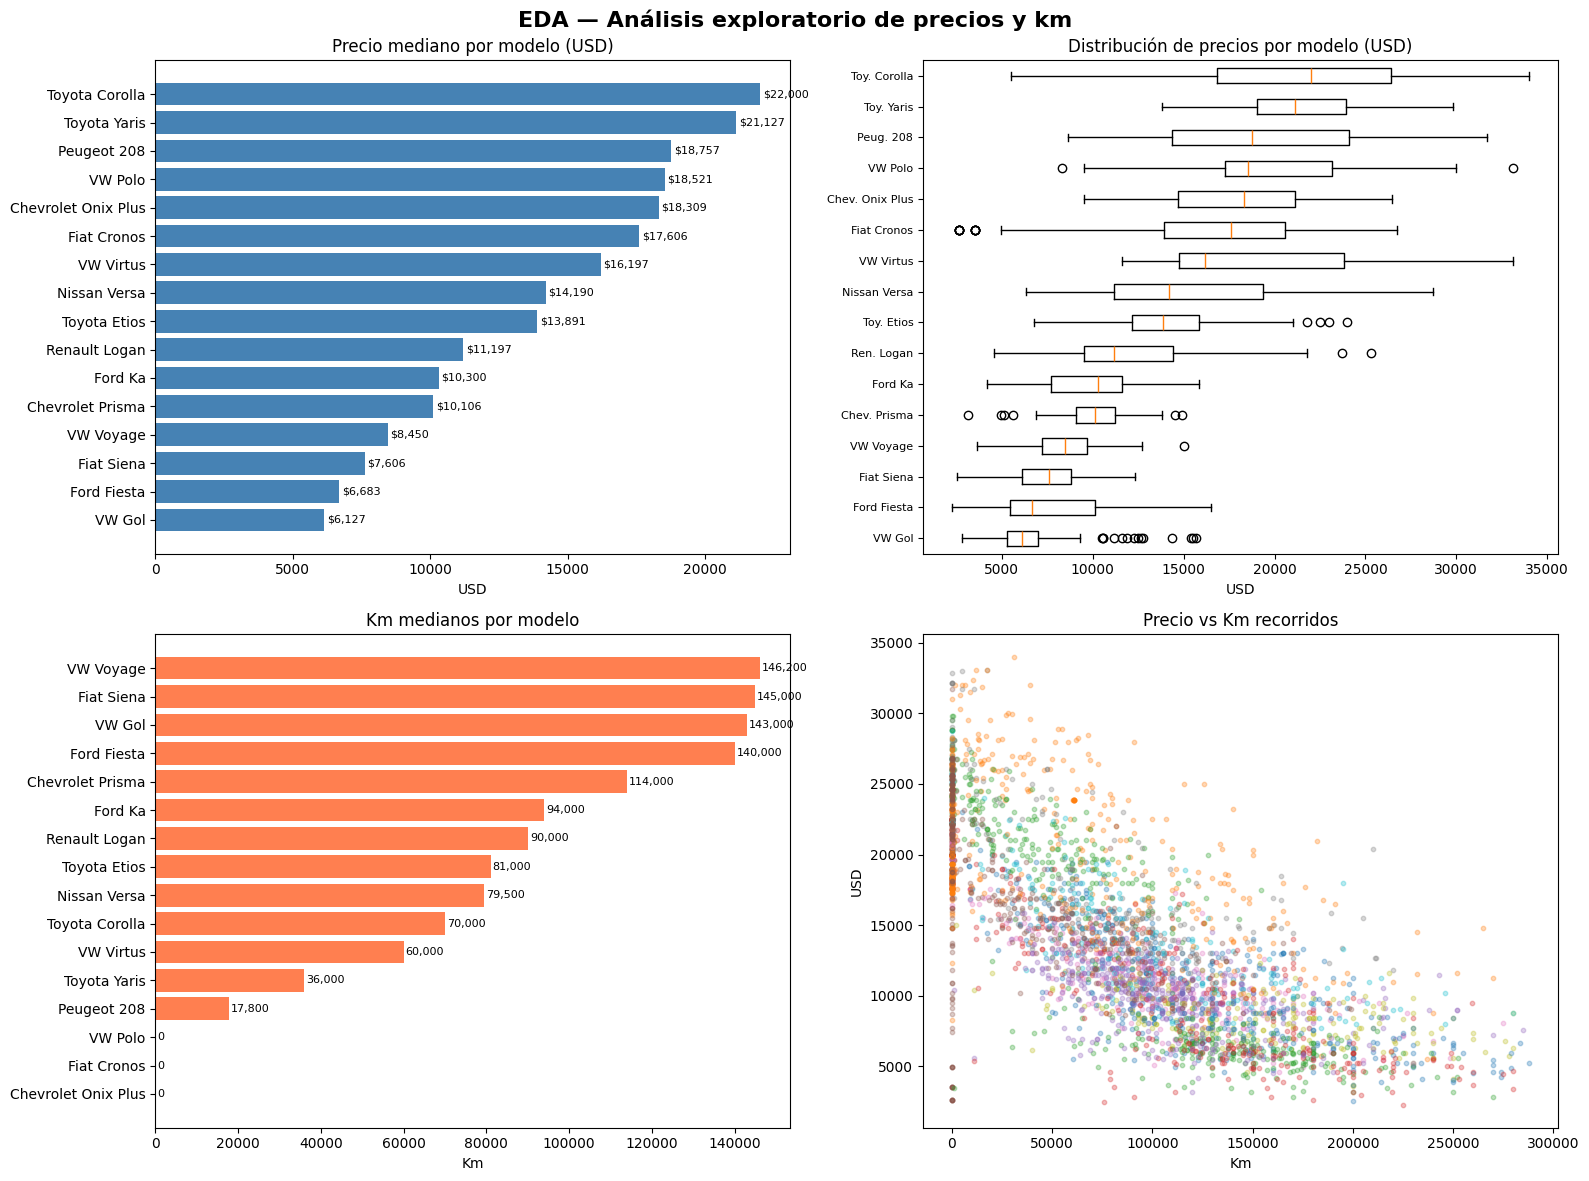

Gráfico guardado en reports/figures/


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EDA — Análisis exploratorio de precios y km", fontsize=16, fontweight="bold")

# 1. Precio promedio por modelo
precio_promedio = df.groupby("modelo")["precio_usd"].median().sort_values(ascending=True)
axes[0, 0].barh(precio_promedio.index, precio_promedio.values, color="steelblue")
axes[0, 0].set_title("Precio mediano por modelo (USD)")
axes[0, 0].set_xlabel("USD")
for i, v in enumerate(precio_promedio.values):
    axes[0, 0].text(v + 100, i, f"${v:,.0f}", va="center", fontsize=8)

# 2. Distribución de precios por modelo — boxplot
modelos_orden = precio_promedio.index.tolist()
df_plot = df[df["modelo"].isin(modelos_orden)]
bp_data = [df_plot[df_plot["modelo"] == m]["precio_usd"].values for m in modelos_orden]
axes[0, 1].boxplot(bp_data, labels=[m.replace("Chevrolet ", "Chev. ").replace("Toyota ", "Toy. ").replace("Renault ", "Ren. ").replace("Peugeot ", "Peug. ") for m in modelos_orden], vert=False)
axes[0, 1].set_title("Distribución de precios por modelo (USD)")
axes[0, 1].set_xlabel("USD")
axes[0, 1].tick_params(axis="y", labelsize=8)

# 3. Km promedio por modelo
km_promedio = df.groupby("modelo")["km_num"].median().sort_values(ascending=True)
axes[1, 0].barh(km_promedio.index, km_promedio.values, color="coral")
axes[1, 0].set_title("Km medianos por modelo")
axes[1, 0].set_xlabel("Km")
for i, v in enumerate(km_promedio.values):
    axes[1, 0].text(v + 500, i, f"{v:,.0f}", va="center", fontsize=8)

# 4. Scatter precio vs km
for modelo in df["modelo"].unique():
    subset = df[df["modelo"] == modelo]
    axes[1, 1].scatter(subset["km_num"], subset["precio_usd"], alpha=0.3, s=10, label=modelo)
axes[1, 1].set_title("Precio vs Km recorridos")
axes[1, 1].set_xlabel("Km")
axes[1, 1].set_ylabel("USD")

plt.tight_layout()
plt.savefig("../reports/figures/01_eda_exploratorio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en reports/figures/")

### Hallazgos del EDA

- **Toyota Corolla y Yaris** son los modelos más caros con mayor dispersión de precios,
  producto de un rango amplio de años y versiones disponibles en el mercado.
- **VW Gol, Ford Fiesta y Fiat Siena** tienen los precios más bajos y menor varianza —
  son commodities cuyo valor de mercado es ampliamente conocido.
- **Correlación negativa precio-km:** a mayor kilometraje, menor precio. Esto valida
  que usaremos km como variable clave en el modelo de depreciación.
- **VW Polo, Fiat Cronos y Chevrolet Onix Plus** muestran km medianos cercanos a 0,
  indicando que su mercado de usados está compuesto principalmente por unidades nuevas o
  casi nuevas — lo que explica también sus precios más elevados.

### Exclusión de modelos sin mercado de usados representativo

Durante el EDA detecté que **VW Polo, Fiat Cronos y Chevrolet Onix Plus** 
tienen una mediana de km cercana a 0, lo que indica que más del 50% de sus 
publicaciones corresponden a unidades 0km.

**¿Por qué es un problema?**
El análisis está orientado a la decisión de compra de un conductor de Cabify,
que opera en el mercado de usados. Sin variedad de km no puedo construir 
una curva de depreciación confiable para estos modelos.

**Decisión:** excluí estos tres modelos del análisis de rentabilidad.
Quedan 13 modelos con mercado de usados representativo.

In [25]:
modelos_excluir = ["VW Polo", "Fiat Cronos", "Chevrolet Onix Plus"]

df = df[~df["modelo"].isin(modelos_excluir)]

print(f"Modelos excluidos: {modelos_excluir}")
print(f"Registros restantes: {len(df)}")
print(f"\nModelos en análisis:")
print(df["modelo"].value_counts())

Modelos excluidos: ['VW Polo', 'Fiat Cronos', 'Chevrolet Onix Plus']
Registros restantes: 3032

Modelos en análisis:
modelo
Toyota Etios        240
Renault Logan       239
Ford Ka             239
Peugeot 208         239
Chevrolet Prisma    238
Nissan Versa        238
Toyota Yaris        235
Ford Fiesta         235
VW Gol              233
VW Virtus           231
VW Voyage           227
Fiat Siena          221
Toyota Corolla      217
Name: count, dtype: int64


In [26]:
# guardo el dataset definitivo 
df.to_csv("../data/processed/precios_autos_final.csv", index=False)
print("Dataset final guardado.")

Dataset final guardado.
